# Clustering


Let's try clustering communes by thes factors using K-Means method

- RGA Houses Exposure
- Innondations Houses Exposure
- CatNat in the last 20 years
- Recognised vs UnRecognised CatNat Ratio
- Median Weight of Insurance in Budget
- Median Revenue
- Median Unemployment


Idées:

- Virer ICB si on cluster que sur les RGA
- Récupérer chomage depuis ODIS
- Regarder évolution des primes (en plus du ratio)
- Ajouter les penalités sur les franchise comme pondération des catnats (1 catnat avec franchise doublée = 2 catnats etc, 1 catnat non reconnue = 5 catnats)
- Regardes les primes vs 'Dépenses de fonctionnement'
- Revenuu disponible vs revenu median

Pour les données


## Load tools & parameters


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import duckdb

In [34]:
# ODIS_DUCKDB_FILE = "odis.duckdb"
def run_duckdb_query(q):
    PCC_DUCKDB_FILE = "dev.duckdb"

    con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
    con.sql(f"ATTACH '{PCC_DUCKDB_FILE}' AS pcc;")
    res = con.sql(q)
    df = res.df()
    con.close()
    return df

In [57]:
QUANT_ECRET = 0.05
CATNAT_CODES = ['SEC',  'ICB'] #'IRN',
LOOKBACK_YEAR = 2005

## Gather Features


### Fetch Communes Geometries


In [35]:
# Fetch communes with geometries
com = gpd.read_file('../csv_large/a-com2022-topo-2154.json', layer='a_com2022')
com.set_geometry('geometry', crs='EPSG:2154', inplace=True)
com = com.drop(columns=['xcl2154', 'ycl2154', 'id'])
com.head()

,codgeo,dep,reg,libgeo,geometry
0,01001,01,84,L'Abergement-Clémenciat,"POLYGON ((846981.436 6564107.36, 847017.457 65..."
1,01002,01,84,L'Abergement-de-Varey,"POLYGON ((886027.651 6548170.9, 886157.325 654..."
2,01004,01,84,Ambérieu-en-Bugey,"POLYGON ((884889.404 6539629.931, 884795.75 65..."
3,01005,01,84,Ambérieux-en-Dombes,"POLYGON ((845951.25 6547999.078, 846073.72 654..."
4,01006,01,84,Ambléon,"POLYGON ((901336.361 6521123.305, 902460.201 6..."


### Fetch Communes RGA + TRI


In [36]:
# Fetch Communes with houses RGA + TRI risks
risques_nat = pd.read_parquet('../csv/risques_communes_flat.parquet')
risques_nat.head()

,code_commune_insee,total_maisons,rga_1945_1975_faible,rga_1945_1975_moyen,rga_1945_1975_nul,rga_1945_1975_fort,rga_1976_2020_faible,rga_1976_2020_moyen,rga_1976_2020_nul,rga_1976_2020_fort,...,tri_nul_nul,tri_t01_faible,tri_t01_fort,tri_t01_moyen,tri_t02_faible,tri_t02_fort,tri_t02_moyen,tri_t03_faible,tri_t03_fort,tri_t03_moyen
0,01001,358,21,0,0,0,184,2,0,0,...,358,0,0,0,0,0,0,0,0,0
1,01002,168,1,12,0,0,2,25,3,0,...,168,0,0,0,0,0,0,0,0,0
2,01004,3254,337,165,1,0,930,869,11,0,...,3254,0,0,0,0,0,0,0,0,0
3,01005,616,82,0,0,0,328,0,2,0,...,616,0,0,0,0,0,0,0,0,0
4,01006,62,5,0,0,0,13,0,0,0,...,62,0,0,0,0,0,0,0,0,0


In [37]:
#Add RGA and TRI Score + Cleanup
# RGA Score
period_weights = {
    '1945_1975': 0.5,
    '1976_2020': 1.0,
    'post2020': 0.5,
    'pre1945': 0.0
}

severity_weights = {
    'faible': 1.0,
    'moyen': 5.0,
    'fort': 10.0
}

# Calculate refined weighted sum
rga_weighted = 0
for period, p_weight in period_weights.items():
    if p_weight == 0: continue
    for severity, s_weight in severity_weights.items():
        col = f'rga_{period}_{severity}'
        if col in risques_nat.columns:
            rga_weighted += p_weight * s_weight * risques_nat[col]

risques_nat['rga_score'] = rga_weighted

# TRI Score
tri_cols = [c for c in risques_nat.columns if c.startswith('tri_') and not c.endswith('_nul') and not c == 'tri_nul_nul']
tri_weighted = (
    1 * risques_nat[[c for c in tri_cols if 'faible' in c]].sum(axis=1) +
    3 * risques_nat[[c for c in tri_cols if 'moyen' in c]].sum(axis=1) +
    5 * risques_nat[[c for c in tri_cols if 'fort' in c]].sum(axis=1)
)

risques_nat['tri_score'] = tri_weighted
risques_nat = risques_nat[['code_commune_insee', 'total_maisons', 'rga_score', 'tri_score']].rename(columns={'code_commune_insee':'codgeo'})
risques_nat.head()

,codgeo,total_maisons,rga_score,tri_score
0,01001,358,216.5,0
1,01002,168,160.0,0
2,01004,3254,5961.0,0
3,01005,616,404.0,0
4,01006,62,15.5,0


### Fetch CCR Data


In [ ]:
# Fetch CCR Data


ccr_details = pd.read_parquet('../csv_large/ccr_details.parquet')
ccr_details = ccr_details[ccr_details.code_peril.isin(CATNAT_CODES)]
ccr_details = ccr_details[ccr_details.date_debut_evenement.dt.year >= LOOKBACK_YEAR]
# ccr = ccr_details['code_geo'].groupby('code_geo').count()
ccr_details.head()


,code_geo,date_debut_evenement,date_fin_evenement,nom_peril,libelle_avis,code_arrete,code_peril,year
0,07005,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904,ICB,2025
1,07022,2025-11-16,2025-11-17,Inondations et/ou Coulées de Boue,Reconnue,904,ICB,2025
2,07181,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904,ICB,2025
3,07198,2025-11-15,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904,ICB,2025
4,07219,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Reconnue,904,ICB,2025


In [39]:
# Let's Group by CVatNat recognition
ccr = ccr_details.groupby('code_geo').size().to_frame(name='catnat_total')

ccr['catnat_rec'] = ccr_details[ccr_details['libelle_avis'] == 'Reconnue'].groupby('code_geo').size()
ccr['catnat_unrec'] = ccr_details[ccr_details['libelle_avis'] == 'Non reconnue'].groupby('code_geo').size()
ccr['catnat_rec_ratio'] = ccr['catnat_rec'] / ccr['catnat_total']

ccr = ccr.fillna(0).astype(float).reset_index()
ccr = ccr.rename(columns={'code_geo':'codgeo'})
ccr.head()

,codgeo,catnat_total,catnat_rec,catnat_unrec,catnat_rec_ratio
0,01001,1.0,1.0,0.0,1.000000
1,01004,8.0,5.0,3.0,0.625000
2,01007,8.0,7.0,1.0,0.875000
3,01012,3.0,2.0,1.0,0.666667
4,01013,1.0,1.0,0.0,1.000000


### Fetch Primes + Budget


In [40]:
# Collect the line 6161 from communes budget
primes = pd.read_parquet('../csv/primes_com_flat.parquet').rename(columns={'code_geo':'codgeo'})
primes['primes_median'] = primes.filter(regex='^primes_').median(axis=1)
primes = primes[['codgeo','primes_median']]
primes.head()

,codgeo,primes_median
0,54162,13361.04
1,54180,1890.62
2,54199,5910.81
3,83128,10902.91
4,83129,185749.05


In [41]:
# Import budget dataframe efficiently (file is huge)
usecols=['annee_join', 'com_code', 'agregat', 'montant', 'ptot']
budgets = pd.read_parquet('../csv_large/ofgl-base-communes-consolidee_2.parquet', columns=usecols, filters=[('annee_join', '==', '2024'),('agregat', '==', 'Dépenses de fonctionnement')])
budgets = budgets[['com_code','annee_join','montant','ptot']].rename(columns={'com_code':'codgeo', 'annee_join':'budget_annee', 'montant':'budget_total', 'ptot':'pop_totale'})
budgets.head()

,codgeo,budget_annee,budget_total,pop_totale
0,01204,2024,865297.74,762
1,01015,2024,460647.32,682
2,01187,2024,1512845.81,627
3,01080,2024,1107315.54,660
4,01426,2024,2381631.87,2552


### Fetch Revenus Médian


In [42]:
q = """
SELECT *
FROM dev.main.insee_filosofi_2021
--LIMIT 1000
"""

rev = run_duckdb_query(q)
rev = rev[
    (rev.geo_object == 'COM')
    & (rev.time_period == 2021)
    & (rev.filosofi_measure == 'MED_SL')
][['code_geo', 'obs_value']].rename(columns={'code_geo':'codgeo', 'obs_value':'med_rev'})
rev.head()

,codgeo,med_rev
13,02399,23300.0
22,01368,23300.0
60,01282,25470.0
62,01200,23480.0
86,01398,26370.0


### Fetch Chomage


In [43]:
# q = """
# SELECT *
# FROM dev.main.taux_chomage_communes
# -- LIMIT 1000
# """

# chomage = run_duckdb_query(q)

chomage = pd.read_csv('../csv_large/DS_RP_EMPLOI_LR_COMP_2022_data.csv', delimiter=';', usecols=['GEO', 'OBS_VALUE', 'TIME_PERIOD', 'PCS', 'GEO_OBJECT','EMPSTA_ENQ'], low_memory=False)
chomage = chomage[
    (chomage.GEO_OBJECT == 'COM')
    & (chomage.PCS == '_T')
    & (chomage.TIME_PERIOD == 2022)
][['GEO', 'EMPSTA_ENQ', 'OBS_VALUE']]
chomage = chomage[chomage.EMPSTA_ENQ == '1T2'].merge(chomage[chomage.EMPSTA_ENQ == '1'], on='GEO', how='left')
chomage['chomage_tx'] = (chomage.OBS_VALUE_x - chomage.OBS_VALUE_y) / chomage.OBS_VALUE_x
chomage = chomage[['GEO', 'chomage_tx']].rename(columns={'GEO':'codgeo'})
chomage.head()

,codgeo,chomage_tx
0,02809,0.000000
1,02486,0.100000
2,02271,0.071429
3,02716,0.040000
4,02790,0.200000


In [44]:
chomage = chomage

chomage_flat.head()

,GEO,EMPSTA_ENQ_x,OBS_VALUE_x,EMPSTA_ENQ_y,OBS_VALUE_y,chomage_tx
0,02809,1T2,30.0,1,30.0,0.000000
1,02486,1T2,53.0,1,47.7,0.100000
2,02271,1T2,77.0,1,71.5,0.071429
3,02716,1T2,125.0,1,120.0,0.040000
4,02790,1T2,108.0,1,86.4,0.200000


### Join all datapoints


In [45]:
# Mega Join
full = com.copy()
full = full.merge(risques_nat, on='codgeo', how='left')
full = full.merge(ccr, on='codgeo', how='left')
full = full.merge(primes, on='codgeo', how='left')
full = full.merge(budgets, on='codgeo', how='left')
full = full.merge(rev, on='codgeo', how='left')
full = full.merge(chomage, on='codgeo', how='left')

In [48]:
full['primes_ratio'] = full['primes_median'] / full['pop_totale']
full['rga_score_scaled'] = full['rga_score'] / full['total_maisons']
full['tri_score_scaled'] = full['tri_score'] / full['total_maisons']
full['catnat_ratio'] = full['catnat_total'] / full['pop_totale']
full.head(1)

,codgeo,dep,reg,libgeo,geometry,total_maisons,rga_score,tri_score,catnat_total,catnat_rec,...,primes_median,budget_annee,budget_total,pop_totale,med_rev,chomage_tx,primes_ratio,rga_score_scaled,tri_score_scaled,catnat_ratio
0,01001,01,84,L'Abergement-Clémenciat,"POLYGON ((846981.436 6564107.36, 847017.457 65...",358.0,216.5,0.0,1.0,1.0,...,6602.17,2024,595097.77,848.0,25820.0,0.021739,7.785578,0.604749,0.0,0.001179


In [47]:
full.to_parquet('../csv_large/com_with_vuln_factors.parquet')

In [49]:
full.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 37034 entries, 0 to 37033
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   codgeo            37034 non-null  str     
 1   dep               37034 non-null  str     
 2   reg               37034 non-null  str     
 3   libgeo            37034 non-null  str     
 4   geometry          37034 non-null  geometry
 5   total_maisons     36802 non-null  float64 
 6   rga_score         36802 non-null  float64 
 7   tri_score         36802 non-null  float64 
 8   catnat_total      26048 non-null  float64 
 9   catnat_rec        26048 non-null  float64 
 10  catnat_unrec      26048 non-null  float64 
 11  catnat_rec_ratio  26048 non-null  float64 
 12  primes_median     31537 non-null  float64 
 13  budget_annee      37007 non-null  str     
 14  budget_total      37007 non-null  float64 
 15  pop_totale        37007 non-null  float64 
 16  med_rev       

## Clusterings


### Clustering with K-Means


In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats.mstats import winsorize


In [74]:
# Let's prepare the data

# 1. On remplace les ratios vides (pas de CatNat historique) par la médiane ou 1 (reconnaissance par défaut)
cols_to_load = ['codgeo', 'rga_score_scaled', 'tri_score_scaled', 'catnat_rec_ratio', 'med_rev', 'primes_ratio', 'catnat_ratio', 'geometry']#, 'chomage_tx']
df = pd.read_parquet('../csv_large/com_with_vuln_factors.parquet', columns=cols_to_load, filters=[('catnat_total', '>', 0.0)])
df['geometry'] = gpd.GeoSeries.from_wkb(df['geometry'])
# df['catnat_rec_ratio'] = df['catnat_rec_ratio'].fillna(1)


# 2. On enlève ou remplace les valeurs manquantes + écrettage

df['catnat_rec_ratio'] = df['catnat_rec_ratio'].fillna(1)
df['catnat_ratio'] = df['catnat_ratio'].fillna(0)
df = df.dropna(how='any')

features = [
    'rga_score_scaled', 
    'catnat_rec_ratio', 
    'primes_ratio', 
    'catnat_ratio', 
    'med_rev', 
    # 'catnat_total', 
    # 'tri_score_scaled', 
    # 'chomage_tx'
    ]

for feat in features:
    df[f'{feat}_win'] = winsorize(df[feat], limits=[QUANT_ECRET, QUANT_ECRET])

features = [feat+'_win' for feat in features] 
X = df[features].copy()


(20703, 13)


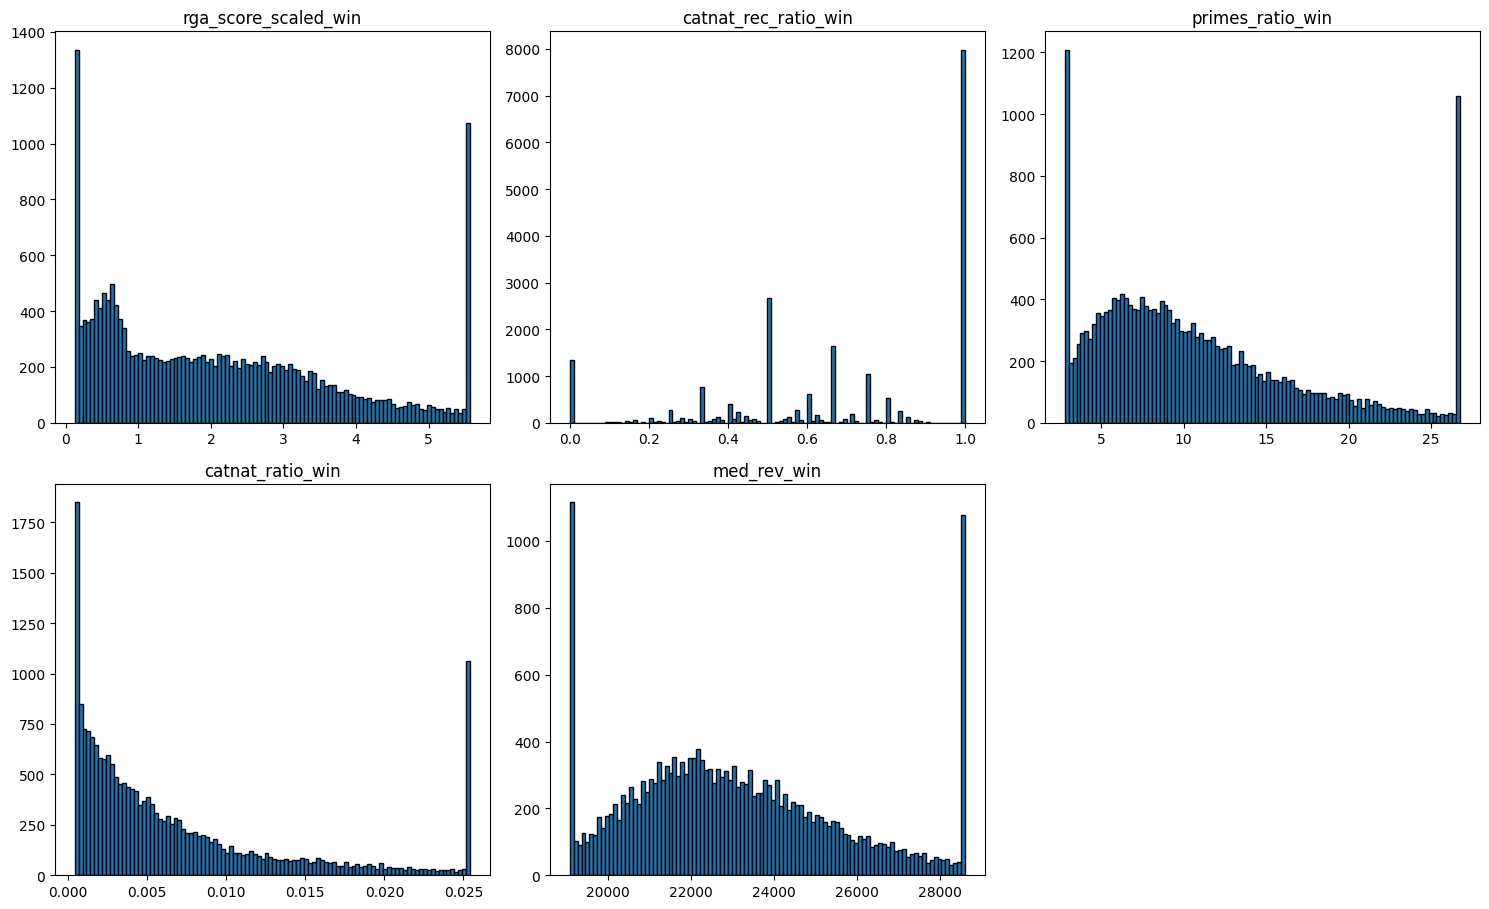

In [75]:
# 3. Standardisation 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# X_scaled = scaler.fit_transform(X_imputed)

print(df.shape)

# Check distribution
df[features].hist(bins=100, figsize=(15, 10), layout=(2, 3), grid=False, edgecolor='black')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [77]:
# 4. Modélisation K-Means 
K_CLUSTERS = 5
kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, df['cluster'])
print(f"Silhouette Score: {score}")

# 5. Extraction du sens : Profilage des clusters (Expliquer le 'Pourquoi')
profile = df.groupby('cluster')[features].mean().round(3)
profile['nb_communes'] = df.groupby('cluster').size()


# Define columns based on whether higher values are positive or negative indicators
cols_high_is_bad = ['rga_score_scaled_win', 'primes_ratio_win', 'catnat_ratio_win']
cols_high_is_good = [c for c in features if c not in cols_high_is_bad]

profile.style\
    .background_gradient(cmap='RdYlGn', subset=cols_high_is_good, axis=0)\
    .background_gradient(cmap='RdYlGn_r', subset=cols_high_is_bad, axis=0)\
    .background_gradient(cmap='Blues', subset=['nb_communes'], axis=0)\
    .format(precision=3)



Silhouette Score: 0.22895129006730897


,rga_score_scaled_win,catnat_rec_ratio_win,primes_ratio_win,catnat_ratio_win,med_rev_win,nb_communes
cluster,,,,,,
0,2.641,0.538,15.120,0.021,21945.566,2756
1,1.193,0.942,7.981,0.003,23201.286,6508
2,1.178,0.875,20.798,0.007,21300.572,2971
3,4.063,0.620,7.566,0.005,25525.588,4241
4,1.747,0.337,9.137,0.005,22341.027,4227


In [79]:
#[Optional] Identify optimum cluster count
# results = []
# for k in range(2, 9):
#     model = KMeans(n_clusters=k, random_state=42, n_init='auto')
#     labels = model.fit_predict(X_scaled)
#     score = silhouette_score(X_scaled, labels)
#     results.append({'k': k, 'silhouette': score})

# # 3. Affichage des scores
# perf_df = pd.DataFrame(results)
# perf_df.head(10)

<Axes: >

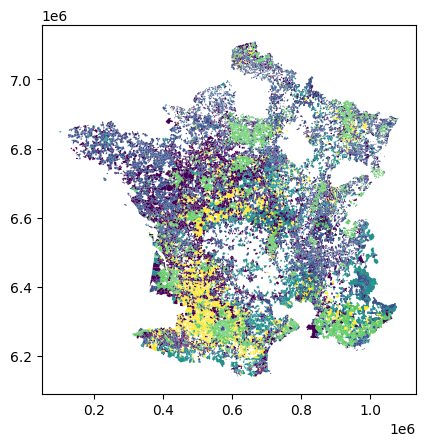

In [328]:
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:2153')
gdf.plot(column='cluster')

### Clustering with AgglomerativeClustering


In [80]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# 1. Chargement et Préparation (sur les données propres et écrêtées)
cols_to_load = ['codgeo', 'rga_score_scaled', 'tri_score_scaled', 'catnat_rec_ratio', 'med_rev', 'primes_ratio', 'catnat_ratio']#, 'geometry']#, 'chomage_tx']
df = pd.read_parquet('../csv_large/com_with_vuln_factors.parquet', columns=cols_to_load, filters=[('catnat_total', '>', 0.0)])
# df['geometry'] = gpd.GeoSeries.from_wkb(df['geometry'])

# On garde nos features clés (en écrêtant la ligne budgétaire extrême)
df['catnat_rec_ratio'] = df['catnat_rec_ratio'].fillna(1)
df['catnat_ratio'] = df['catnat_ratio'].fillna(0)
df = df.dropna(how='any')

features = [
    'rga_score_scaled', 
    'catnat_rec_ratio', 
    'primes_ratio', 
    'catnat_ratio', 
    'med_rev', 
    # 'catnat_total', 
    # 'tri_score_scaled', 
    # 'chomage_tx'
    ]

for feat in features:
    df[f'{feat}_win'] = winsorize(df[feat], limits=[QUANT_ECRET, QUANT_ECRET])

features = [feat+'_win' for feat in features] 
X = df[features].copy()

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Le Modèle Agglomératif
# On lui demande 5 clusters
model_hc = AgglomerativeClustering(n_clusters=7, linkage='ward')
X['cluster_hc'] = model_hc.fit_predict(X_scaled)

# 3. Profilage pour trouver le cluster "Double Peine"
profil_hc = X.groupby('cluster_hc').mean().round(2)
profil_hc['nb_communes'] = X.groupby('cluster_hc').size()

In [82]:
cols_high_is_bad = ['rga_score_scaled_win', 'primes_ratio_win', 'catnat_ratio_win']
cols_high_is_good = [c for c in features if c not in cols_high_is_bad]

profil_hc.style\
    .background_gradient(cmap='RdYlGn', subset=cols_high_is_good, axis=0)\
    .background_gradient(cmap='RdYlGn_r', subset=cols_high_is_bad, axis=0)\
    .background_gradient(cmap='Blues', subset=['nb_communes'], axis=0)\
    .format(precision=3)

,rga_score_scaled_win,catnat_rec_ratio_win,primes_ratio_win,catnat_ratio_win,med_rev_win,nb_communes
cluster_hc,,,,,,
0,2.640,0.570,15.590,0.020,22123.030,2489
1,2.970,0.540,8.830,0.010,22845.820,4946
2,0.880,0.870,9.950,0.000,21679.040,5607
3,1.910,0.930,7.880,0.000,25486.300,3555
4,1.430,0.840,24.120,0.010,21409.820,1538
5,4.490,0.530,6.410,0.000,27007.900,1366
6,1.500,0.010,11.630,0.000,22804.140,1202
